<a href="https://colab.research.google.com/github/BielPatu/IATumorDetector/blob/main/ModeloDetectadorTumores.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task
Desenvolver um programa em Python para classificar imagens de tumores cerebrais utilizando aprendizado de máquina, incluindo o treinamento de um modelo e a avaliação de seu desempenho.

## Carregar dados

### Subtask:
Carregue as imagens do conjunto de dados baixado.


In [ ]:
import kagglehub

path = kagglehub.dataset_download("navoneel/brain-mri-images-for-brain-tumor-detection")

print("Path to dataset files:", path)

import os
import cv2
import numpy as np

image_list = []
label_list = []

for label_dir in os.listdir(path):
    label_path = os.path.join(path, label_dir)
    if os.path.isdir(label_path):
        for image_file in os.listdir(label_path):
            image_path = os.path.join(label_path, image_file)
            image = cv2.imread(image_path)
            if image is not None:
                image_list.append(image)
                label_list.append(label_dir)

print(f"Loaded {len(image_list)} images.")

Using Colab cache for faster access to the 'brain-mri-images-for-brain-tumor-detection' dataset.
Path to dataset files: /kaggle/input/brain-mri-images-for-brain-tumor-detection
Loaded 253 images.


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

IMG_SIZE = 128
resized_images = []
for img in image_list:
    resized_img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    resized_images.append(resized_img)

images_np = np.array(resized_images)
labels_np = np.array(label_list)

images_normalized = images_np / 255.0

label_encoder = LabelEncoder()
labels_encoded = label_encoder.fit_transform(labels_np)

X_train, X_test, y_train, y_test = train_test_split(
    images_normalized, labels_encoded, test_size=0.2, random_state=42
)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")
print(f"Training labels shape: {y_train.shape}")
print(f"Testing labels shape: {y_test.shape}")

Training set shape: (202, 128, 128, 3)
Testing set shape: (51, 128, 128, 3)
Training labels shape: (202,)
Testing labels shape: (51,)


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(len(np.unique(labels_encoded)), activation='softmax')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,898 (12.61 MB)

 Trainable params: 3,304,898 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

## Treinar Diferentes modelos

Indentificar quais deles são os melhores para detecção de tumores.
O teste fará um treino semelhante para cada modelo em 25 gerações.


**Reasoning**:
Compile and train the defined model using the training data and store the training history.




Treinando com otimizador: SGD

Treinando com otimizador: RMSprop

Treinando com otimizador: Adam

Treinando com otimizador: Adamax

Treinando com otimizador: Adagrad

Treinando com otimizador: Adadelta

Treinando com otimizador: Nadam

Resumo dos resultados por otimizador:
SGD -> Acurácia de Validação: 0.8235 | Acurácia de Treino: 0.8713
RMSprop -> Acurácia de Validação: 0.9020 | Acurácia de Treino: 1.0000
Adam -> Acurácia de Validação: 0.8824 | Acurácia de Treino: 1.0000
Adamax -> Acurácia de Validação: 0.8824 | Acurácia de Treino: 1.0000
Adagrad -> Acurácia de Validação: 0.7451 | Acurácia de Treino: 0.8020
Adadelta -> Acurácia de Validação: 0.6078 | Acurácia de Treino: 0.6139
Nadam -> Acurácia de Validação: 0.9020 | Acurácia de Treino: 1.0000


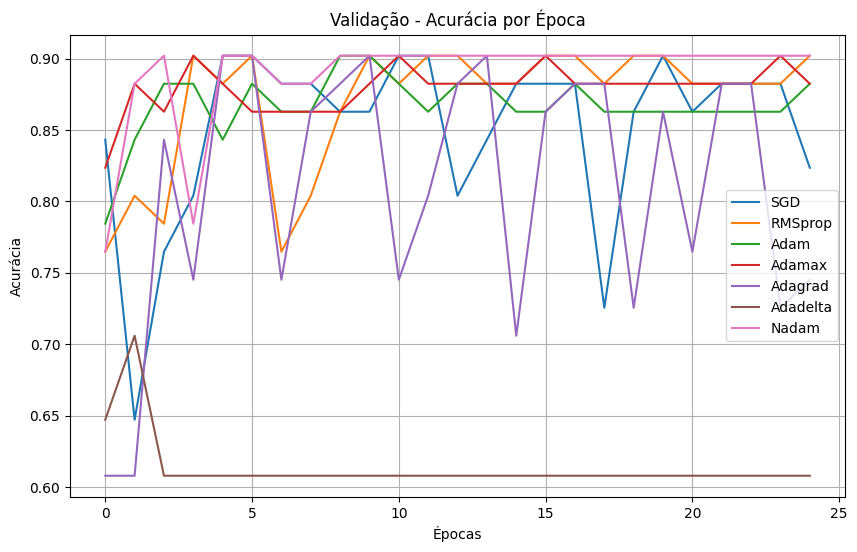

In [ ]:
import tensorflow as tf
from tensorflow.keras.optimizers import SGD, RMSprop, Adam, Adamax, Adagrad, Adadelta, Nadam
import matplotlib.pyplot as plt


optimizers = {
    'SGD': SGD(),
    'RMSprop': RMSprop(),
    'Adam': Adam(),
    'Adamax': Adamax(),
    'Adagrad': Adagrad(),
    'Adadelta': Adadelta(),
    'Nadam': Nadam()
}

results = {}

for name, optimizer in optimizers.items():
    print(f"\nTreinando com otimizador: {name}")


    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(128, 128, 3)),
        tf.keras.layers.Conv2D(32, (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dense(2, activation='softmax')
    ])

    model.compile(optimizer=optimizer,
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

    history = model.fit(X_train, y_train,
                        epochs=25,
                        batch_size=32,
                        validation_data=(X_test, y_test),
                        verbose=0)

    results[name] = {
        'train_acc': history.history['accuracy'][-1],
        'val_acc': history.history['val_accuracy'][-1],
        'history': history
    }

print("\nResumo dos resultados por otimizador:")
for opt, res in results.items():
    print(f"{opt} -> Acurácia de Validação: {res['val_acc']:.4f} | Acurácia de Treino: {res['train_acc']:.4f}")

plt.figure(figsize=(10, 6))
for name, res in results.items():
    plt.plot(res['history'].history['val_accuracy'], label=name)

plt.title("Validação - Acurácia por Época")
plt.xlabel("Épocas")
plt.ylabel("Acurácia")
plt.legend()
plt.grid(True)
plt.show()


## Construir modelo

### Subtask:
Defina a arquitetura do modelo de classificação de imagens usando uma biblioteca como TensorFlow ou PyTorch.



In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(len(np.unique(labels_encoded)), activation='softmax')
])

model.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_17 (Conv2D)              │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_8 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,898 (12.61 MB)

 Trainable params: 3,304,898 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

##Adam foi o otimizador escolhido para nossos testes



In [ ]:
model.compile(optimizer='Adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(X_train, y_train, epochs=14, batch_size=32, validation_data=(X_test, y_test))

Epoch 1/14
7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 474ms/step - accuracy: 0.5208 - loss: 0.7863 - val_accuracy: 0.8431 - val_loss: 0.5401
Epoch 2/14
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.7338 - loss: 0.5529 - val_accuracy: 0.9020 - val_loss: 0.3741
Epoch 3/14
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.7530 - loss: 0.5547 - val_accuracy: 0.8235 - val_loss: 0.4451
Epoch 4/14
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.7985 - loss: 0.4791 - val_accuracy: 0.8235 - val_loss: 0.4111
Epoch 5/14
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.8302 - loss: 0.3976 - val_accuracy: 0.8235 - val_loss: 0.4085
Epoch 6/14
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.8577 - loss: 0.3556 - val_accuracy: 0.8235 - val_loss: 0.4274
Epoch 7/14
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.8172 - loss: 0.3748 - val_accuracy: 0.9020 - val_loss: 0.3540
Epoch 8/14
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.8734 - loss: 0.2689 - val_accuracy: 0.8039 - val_loss: 0.4246

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

y_pred_prob = model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)

conf_matrix = confusion_matrix(y_test, y_pred)

class_report = classification_report(y_test, y_pred)

print("Confusion Matrix:")
print(conf_matrix)
print("\nClassification Report:")
print(class_report)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 545ms/step
Confusion Matrix:
[[17  3]
 [ 7 24]]

Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.85      0.77        20
           1       0.89      0.77      0.83        31

    accuracy                           0.80        51
   macro avg       0.80      0.81      0.80        51
weighted avg       0.82      0.80      0.81        51



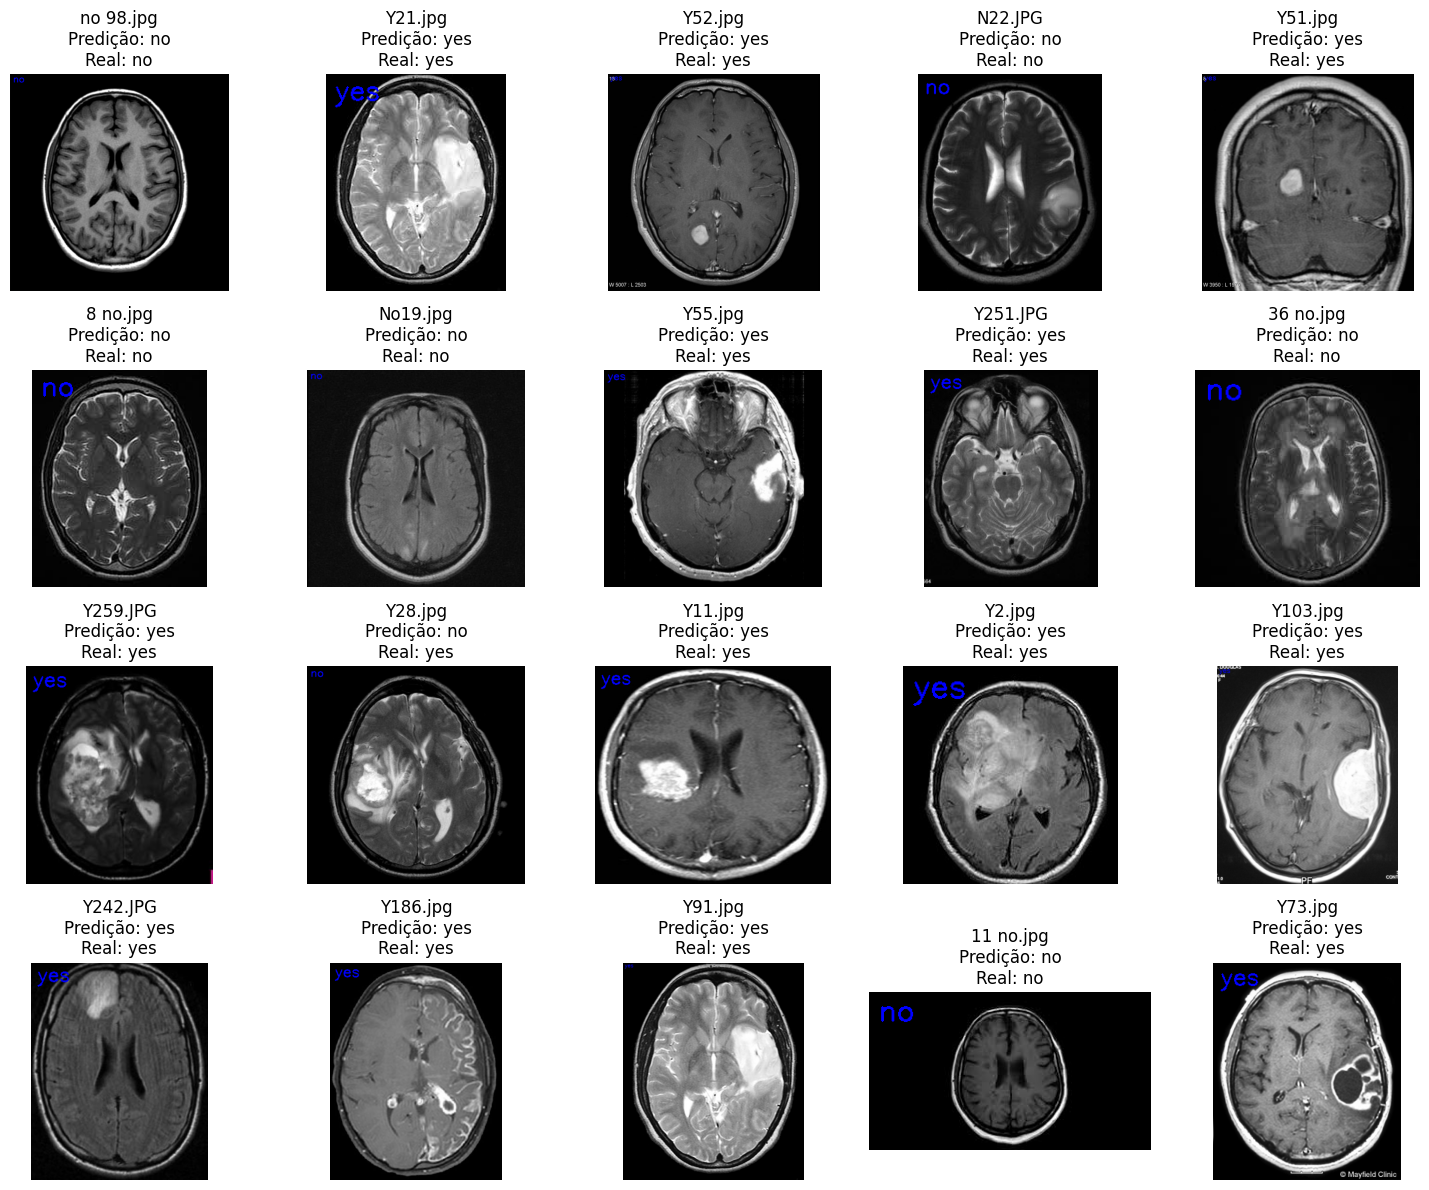

In [ ]:
import math
import random
import matplotlib.pyplot as plt
import cv2
import numpy as np
import os
import tensorflow as tf
from sklearn.preprocessing import LabelEncoder


all_image_paths = []
for label_dir in os.listdir(path):
    label_path = os.path.join(path, label_dir)
    if os.path.isdir(label_path):
        for image_file in os.listdir(label_path):
            image_path = os.path.join(label_path, image_file)
            all_image_paths.append(image_path)

num_images_to_display = min(20, len(all_image_paths))
selected_image_paths = random.sample(all_image_paths, num_images_to_display)

num_images = len(selected_image_paths)
n_cols = 5
n_rows = math.ceil(num_images / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 3, n_rows * 3))
axes = axes.flatten()

for i, image_path in enumerate(selected_image_paths):
    new_image = cv2.imread(image_path)

    if new_image is not None:
        actual_label = os.path.basename(os.path.dirname(image_path))

        resized_new_image = cv2.resize(new_image, (IMG_SIZE, IMG_SIZE))
        normalized_new_image = resized_new_image / 255.0
        reshaped_new_image = np.expand_dims(normalized_new_image, axis=0)

        prediction = model.predict(reshaped_new_image, verbose=0)
        predicted_class_index = np.argmax(prediction, axis=1)[0]
        predicted_label = label_encoder.inverse_transform([predicted_class_index])[0]

        font = cv2.FONT_HERSHEY_SIMPLEX
        cv2.putText(new_image, predicted_label, (10, 30), font, 1, (255, 0, 0), 2)

        ax = axes[i]
        ax.imshow(cv2.cvtColor(new_image, cv2.COLOR_BGR2RGB))
        ax.set_title(f"{os.path.basename(image_path)}\nPredição: {predicted_label}\nReal: {actual_label}")
        ax.axis('off')
    else:
        print(f"Erro ao carregar a imagem: {image_path}")
        axes[i].axis('off')

for j in range(num_images, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()


##MVP DO PROJETO


In [ ]:
!pip install -q streamlit
!pip install -q pyngrok


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 120.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 127.2 MB/s eta 0:00:00


In [ ]:
%%writefile app.py
import streamlit as st
import cv2
import numpy as np
import tensorflow as tf
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import os
from glob import glob
import kagglehub

IMG_SIZE = 128
DATASET_PATH = kagglehub.dataset_download("navoneel/brain-mri-images-for-brain-tumor-detection")
checkpoint_path = "melhor_modelo.keras"

@st.cache_data(show_spinner=False)
def carregar_dados():
    imagens = []
    labels = []
    for rotulo in ['yes', 'no']:
        caminho = os.path.join(DATASET_PATH, rotulo)
        arquivos = glob(caminho + "/*.jpg")
        for arquivo in arquivos:
            img = cv2.imread(arquivo)
            if img is None:
                continue
            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            imagens.append(img)
            labels.append(rotulo)
    imagens = np.array(imagens) / 255.0
    le = LabelEncoder()
    labels_encoded = le.fit_transform(labels)
    return imagens, labels_encoded, le

def criar_modelo():
    model = tf.keras.models.Sequential([
        tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Conv2D(128, (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dense(2, activation='softmax')
    ])
    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

st.title("🧠 Detecção de Tumores Cerebrais com Deep Learning")

if "label_encoder" not in st.session_state:
    with st.spinner("📥 Carregando dados..."):
        X, y, le = carregar_dados()
        st.session_state.X_train, st.session_state.X_test, st.session_state.y_train, st.session_state.y_test = train_test_split(X, y, test_size=0.2, random_state=42)
        st.session_state.label_encoder = le
    st.success("Dados carregados!")

if "modelo" not in st.session_state:
    if os.path.exists(checkpoint_path):
        st.session_state.modelo = tf.keras.models.load_model(checkpoint_path)
        st.session_state.treinado = True
        st.info("Modelo carregado do checkpoint.")
    else:
        st.session_state.modelo = criar_modelo()
        st.session_state.treinado = False
        st.info("Modelo criado do zero.")

if st.session_state.treinado:
    loss_before, acc_before = st.session_state.modelo.evaluate(st.session_state.X_test, st.session_state.y_test, verbose=0)
    st.metric("🎯 Acurácia antes do treino", f"{acc_before:.2%}")
else:
    loss_before, acc_before = None, None
    st.write("Modelo ainda não treinado.")

if st.button("🧠 Treinar Modelo (Continuação)"):
    st.write("🔄 Treinamento iniciado...")
    checkpoint_cb = tf.keras.callbacks.ModelCheckpoint(
        filepath=checkpoint_path,
        save_best_only=True,
        monitor='val_accuracy',
        mode='max',
        verbose=1
    )
    with st.spinner("🔁 Treinando modelo..."):
        history = st.session_state.modelo.fit(
            st.session_state.X_train,
            st.session_state.y_train,
            epochs=5,
            batch_size=32,
            validation_data=(st.session_state.X_test, st.session_state.y_test),
            callbacks=[checkpoint_cb],
            verbose=1
        )
    st.session_state.treinado = True
    loss_after, acc_after = st.session_state.modelo.evaluate(st.session_state.X_test, st.session_state.y_test, verbose=0)

    logs = []
    for i in range(len(history.history['loss'])):
        logs.append(
            f"Época {i+1}: loss={history.history['loss'][i]:.4f}, val_loss={history.history['val_loss'][i]:.4f}, val_acc={history.history['val_accuracy'][i]:.4f}"
        )
    st.subheader("📋 Histórico do último treino (5 épocas)")
    st.code("\n".join(logs))

    if acc_before is not None:
        st.success(f"✅ Treinamento concluído! Acurácia antes: {acc_before:.2%}, depois: {acc_after:.2%}")
    else:
        st.success(f"✅ Treinamento concluído! Acurácia depois: {acc_after:.2%}")

if st.button("♻️ Resetar Treino"):
    st.session_state.modelo = criar_modelo()
    st.session_state.treinado = False
    if os.path.exists(checkpoint_path):
        os.remove(checkpoint_path)
    st.warning("🔁 Treino resetado. Modelo reiniciado e checkpoint apagado.")

uploaded_file = st.file_uploader("📤 Envie uma imagem de ressonância cerebral", type=["jpg", "jpeg", "png"])
true_label = st.selectbox("🧾 Rótulo real da imagem (opcional)", options=["", "Com Tumor", "Sem Tumor"])

if uploaded_file:
    if not st.session_state.treinado:
        st.warning("⚠️ Treine o modelo primeiro antes de realizar predições.")
    else:
        image = Image.open(uploaded_file).convert('RGB')
        img_array = np.array(image)
        resized_img = cv2.resize(img_array, (IMG_SIZE, IMG_SIZE))
        normalized_img = resized_img / 255.0
        input_img = np.expand_dims(normalized_img, axis=0)

        prediction = st.session_state.modelo.predict(input_img, verbose=0)
        predicted_index = np.argmax(prediction)
        internal_label = st.session_state.label_encoder.inverse_transform([predicted_index])[0]
        label_map = {"yes": "Com Tumor", "no": "Sem Tumor"}
        predicted_label = label_map.get(internal_label, internal_label)

        st.image(image, caption="🧾 Imagem Enviada", use_column_width=True)

        st.markdown("### 🔍 Resultado da Classificação:")

        if true_label:
            true_label_map = {
                "Com Tumor": "yes",
                "Sem Tumor": "no"
            }
            true_internal = true_label_map.get(true_label, "").lower()
            pred_internal = internal_label.lower()

            if pred_internal == true_internal:
                st.success(f"✅ Predição correta: **{predicted_label}**")
            else:
                st.error(f"❌ Predição incorreta: **{predicted_label}** (Real: {true_label})")
        else:
            st.info(f"🔎 Predição: **{predicted_label}**")

if st.session_state.treinado:
    loss, acc = st.session_state.modelo.evaluate(st.session_state.X_test, st.session_state.y_test, verbose=0)
    st.metric(label="🎯 Acurácia no Teste", value=f"{acc:.2%}")


Writing app.py


**Próximo Passo:**

Por favor, insira seu token de autenticação do ngrok na célula abaixo. Você pode encontrar seu token na página "Your Authtoken" no painel do ngrok ([https://dashboard.ngrok.com/get-started/your-authtoken](https://dashboard.ngrok.com/get-started/your-authtoken)).

In [ ]:
from pyngrok import ngrok
import getpass

# Digite seu token de autenticação do ngrok quando solicitado.
# Será uma string que começa com "ey..."
ngrok.set_auth_token(getpass.getpass("Digite seu token de autenticação do ngrok: "))

In [ ]:
from pyngrok import ngrok
import subprocess
import time

ngrok.kill()
tunnel_config = {
    "addr": "8501",
    "proto": "http"
}

public_url = ngrok.connect(**tunnel_config)
print("Acesse o app aqui:", public_url)
process = subprocess.Popen(["streamlit", "run", "app.py"], stdout=subprocess.PIPE, stderr=subprocess.PIPE)
time.sleep(5)

